In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)


사용 디바이스: cpu


In [21]:
# 데이터 로딩

housing = fetch_california_housing(as_frame=True)
df = housing.frame   # 피처 + 타깃이 합쳐진 DataFrame

print(f"데이터 크기: {df.shape}")          # (20640, 9)
print(f"\n피처 설명:")
for name, desc in zip(housing.feature_names, housing.DESCR.split('\n')[:30]):
    pass
df.head()


데이터 크기: (20640, 9)

피처 설명:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [22]:
# 피처 의미 확인
feature_info = {
    "MedInc":      "중위 소득 (만 달러)",
    "HouseAge":    "주택 연식 (년)",
    "AveRooms":    "평균 방 수",
    "AveBedrms":   "평균 침실 수",
    "Population":  "블록 인구 수",
    "AveOccup":    "평균 거주 인원",
    "Latitude":    "위도",
    "Longitude":   "경도",
}
print("=== 피처 설명 ===")
for k, v in feature_info.items():
    print(f"  {k:<12}: {v}")
print(f"\n타깃: MedHouseVal — 블록별 주택 중위 가격 ($10만 단위)")
print(f"  예) 값이 3.5 → 실제 가격 $350,000")


=== 피처 설명 ===
  MedInc      : 중위 소득 (만 달러)
  HouseAge    : 주택 연식 (년)
  AveRooms    : 평균 방 수
  AveBedrms   : 평균 침실 수
  Population  : 블록 인구 수
  AveOccup    : 평균 거주 인원
  Latitude    : 위도
  Longitude   : 경도

타깃: MedHouseVal — 블록별 주택 중위 가격 ($10만 단위)
  예) 값이 3.5 → 실제 가격 $350,000


         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%       37.71    -118.01         2.65  
max       41.95

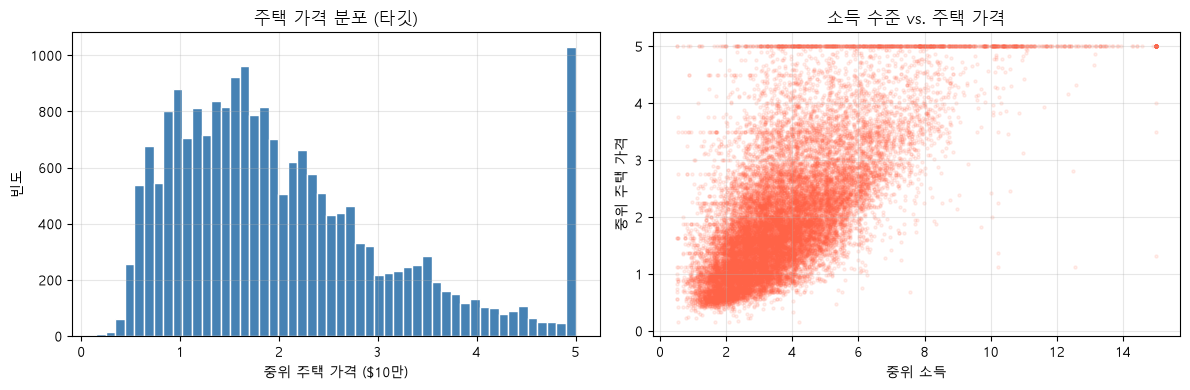

In [23]:
# 기초 통계 및 타깃 분포 시각화
print(df.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["MedHouseVal"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("주택 가격 분포 (타깃)")
axes[0].set_xlabel("중위 주택 가격 ($10만)")
axes[0].set_ylabel("빈도")
axes[0].grid(alpha=0.3)

axes[1].scatter(df["MedInc"], df["MedHouseVal"],
                alpha=0.1, s=5, color="tomato")
axes[1].set_title("소득 수준 vs. 주택 가격")
axes[1].set_xlabel("중위 소득")
axes[1].set_ylabel("중위 주택 가격")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("housing_eda.png", dpi=100, bbox_inches="tight")
plt.show()


In [25]:
# 전처리 - 스케일링

X = housing.data.values.astype("float32")   # (20640, 8)
y = housing.target.values.astype("float32") # (20640,)

# 훈련 / 검증 / 테스트 분리 (6 : 2 : 2)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42  # 0.25 × 0.8 = 0.2
)

print(f"훈련: {X_train.shape} | 검증: {X_val.shape} | 테스트: {X_test.shape}")

# 피처 정규화 — 훈련 세트 통계만 사용 (데이터 누수 방지)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype("float32")
X_val   = scaler.transform(X_val).astype("float32")
X_test  = scaler.transform(X_test).astype("float32")

print(f"\n스케일링 후 훈련 피처 평균: {X_train.mean(axis=0).round(3)}")
print(f"스케일링 후 훈련 피처 표준편차: {X_train.std(axis=0).round(3)}")



훈련: (12384, 8) | 검증: (4128, 8) | 테스트: (4128, 8)

스케일링 후 훈련 피처 평균: [ 0.  0. -0.  0. -0.  0.  0.  0.]
스케일링 후 훈련 피처 표준편차: [1. 1. 1. 1. 1. 1. 1. 1.]


In [26]:
# DataSet, DataLoader 구성

class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE   = 256
train_loader = DataLoader(HousingDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(HousingDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(HousingDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

print(f"훈련 {len(X_train):,}개 ({len(train_loader)} 배치) | "
      f"검증 {len(X_val):,}개 | 테스트 {len(X_test):,}개")


훈련 12,384개 (49 배치) | 검증 4,128개 | 테스트 4,128개


In [27]:
# 모델 정의

# 8 → 128 → 64 → 32 → 1 (선형 회귀 출력)
class HousingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)   # 활성화 함수 없음 — 연속값 출력
        )

    def forward(self, x):
        return self.net(x).squeeze(1)   # (배치, 1) → (배치,)

model = HousingNet().to(device)
print(model)
print(f"전체 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

# 추론 테스트
dummy = torch.randn(4, 8).to(device)
print(f"\n입력 shape:  {dummy.shape}")          # (4, 8)
print(f"출력 shape:  {model(dummy).shape}")     # (4,)
print(f"출력값 예시: {model(dummy).detach()}")   # 연속값 (음수 포함 가능)


HousingNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
전체 파라미터 수: 11,521

입력 shape:  torch.Size([4, 8])
출력 shape:  torch.Size([4])
출력값 예시: tensor([ 0.0104, -0.0621, -0.0691, -0.0796])


In [28]:
EPOCHS = 100
LR     = 0.001

# 회귀 손실함수: MSELoss (잔차 제곱 평균)
# HuberLoss는 이상치에 덜 민감한 대안 — delta 파라미터로 MSE/MAE 전환점 조정
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10
)

history    = {"train_loss": [], "val_loss": [], "val_rmse": []}
best_rmse  = float("inf")

print(f"{'Epoch':>6} | {'Train MSE':>10} | {'Val MSE':>10} | {'Val RMSE':>9}")
print("-" * 45)

for epoch in range(1, EPOCHS + 1):
    # ── 훈련 ──────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        pred = model(X_b)
        loss = criterion(pred, y_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── 검증 ──────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            pred      = model(X_b)
            val_loss += criterion(pred, y_b).item()
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y_b.cpu().numpy())
    val_loss /= len(val_loader)
    # val_rmse  = mean_squared_error(all_labels, all_preds, squared=False)
    val_rmse = root_mean_squared_error(all_labels, all_preds)

    scheduler.step(val_loss)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_rmse"].append(val_rmse)

    if val_rmse < best_rmse:
        best_rmse = val_rmse
        torch.save(model.state_dict(), "housing_best.pt")

    if epoch % 20 == 0:
        print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | {val_rmse:>8.4f}")

print(f"\n최고 검증 RMSE: {best_rmse:.4f} → housing_best.pt 저장")


 Epoch |  Train MSE |    Val MSE |  Val RMSE
---------------------------------------------


    20 |     0.3713 |     0.3314 |   0.5840
    40 |     0.3270 |     0.3041 |   0.5591
    60 |     0.3015 |     0.2849 |   0.5399
    80 |     0.2853 |     0.2791 |   0.5346
   100 |     0.2757 |     0.2611 |   0.5174

최고 검증 RMSE: 0.5174 → housing_best.pt 저장


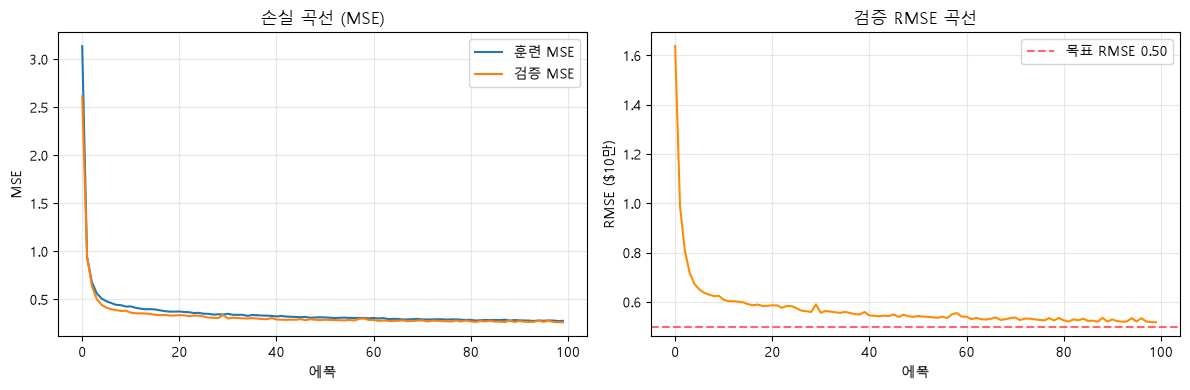

In [29]:
# 학습 곡선 시각화

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="훈련 MSE")
axes[0].plot(history["val_loss"],   label="검증 MSE")
axes[0].set_title("손실 곡선 (MSE)")
axes[0].set_xlabel("에폭")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["val_rmse"], color="darkorange")
axes[1].axhline(y=0.5, color="red", linestyle="--", alpha=0.6, label="목표 RMSE 0.50")
axes[1].set_title("검증 RMSE 곡선")
axes[1].set_xlabel("에폭")
axes[1].set_ylabel("RMSE ($10만)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("housing_training_curve.png", dpi=100, bbox_inches="tight")
plt.show()


In [31]:
# 테스트 평가

# 최고 모델 불러오기
model.load_state_dict(torch.load("housing_best.pt", map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        pred = model(X_b.to(device))
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y_b.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

mae  = mean_absolute_error(all_labels, all_preds)
# rmse = mean_squared_error(all_labels, all_preds, squared=False)
rmse = root_mean_squared_error(all_labels, all_preds)
r2   = r2_score(all_labels, all_preds)

print("=== 테스트 세트 평가 결과 ===")
print(f"  MAE  : {mae:.4f}  (평균 절대 오차, $10만 단위 → 약 ${mae*10:.1f}만)")
print(f"  RMSE : {rmse:.4f}  (이상치에 민감한 오차)")
print(f"  R²   : {r2:.4f}  (1.0에 가까울수록 좋음)")


=== 테스트 세트 평가 결과 ===
  MAE  : 0.3490  (평균 절대 오차, $10만 단위 → 약 $3.5만)
  RMSE : 0.5183  (이상치에 민감한 오차)
  R²   : 0.7950  (1.0에 가까울수록 좋음)


C:\Users\human\AppData\Local\Temp\ipykernel_15612\534040425.py:24: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\human\AppData\Local\Temp\ipykernel_15612\534040425.py:25: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig("housing_evaluation.png", dpi=100, bbox_inches="tight")
c:\Users\human\miniconda3\envs\human-env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


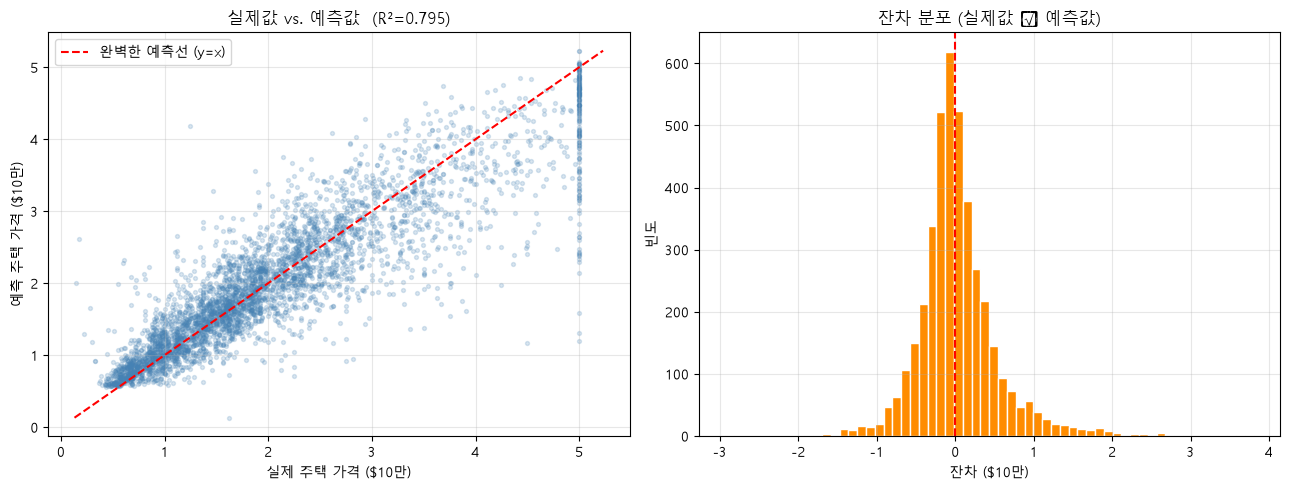

In [32]:
# 예측값 vs. 실제값 산점도
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 산점도
axes[0].scatter(all_labels, all_preds, alpha=0.2, s=8, color="steelblue")
lim = [min(all_labels.min(), all_preds.min()),
       max(all_labels.max(), all_preds.max())]
axes[0].plot(lim, lim, "r--", linewidth=1.5, label="완벽한 예측선 (y=x)")
axes[0].set_xlabel("실제 주택 가격 ($10만)")
axes[0].set_ylabel("예측 주택 가격 ($10만)")
axes[0].set_title(f"실제값 vs. 예측값  (R²={r2:.3f})")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 잔차 분포 (Residual)
residuals = all_labels - all_preds
axes[1].hist(residuals, bins=60, color="darkorange", edgecolor="white")
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("잔차 분포 (실제값 − 예측값)")
axes[1].set_xlabel("잔차 ($10만)")
axes[1].set_ylabel("빈도")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("housing_evaluation.png", dpi=100, bbox_inches="tight")
plt.show()


In [33]:
# 체크포인트 저장

import pickle

# 스케일러도 함께 저장 (추론 시 동일한 변환 필요)
with open("housing_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

torch.save({
    "model_state_dict":     model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_rmse": best_rmse,
    "history":   history,
}, "housing_checkpoint.pt")

print("저장 완료:")
print("  - housing_best.pt        (추론용 — state_dict만)")
print("  - housing_checkpoint.pt  (재훈련용 — 전체 상태)")
print("  - housing_scaler.pkl     (추론 시 피처 스케일링용)")


저장 완료:
  - housing_best.pt        (추론용 — state_dict만)
  - housing_checkpoint.pt  (재훈련용 — 전체 상태)
  - housing_scaler.pkl     (추론 시 피처 스케일링용)
